In [1]:
!pip install torch torchvision numpy pandas matplotlib scikit-learn Pillow 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import (DataLoader, Dataset,
                               WeightedRandomSampler)
from torchvision import models, transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report,
                             roc_curve, auc)
from sklearn.preprocessing import label_binarize

In [3]:
class XRayDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels      = labels
        self.transform   = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

In [4]:
DATASET_PATH = r"C:\Users\bilsr\OneDrive\Desktop\New folder\archive\chest_xray\chest_xray"

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

all_paths  = []
all_labels = []

CLASS_NAMES = ['Normal', 'Bacterial', 'Viral']

for split in ['train', 'test', 'val']:
    normal_folder = os.path.join(DATASET_PATH, split, 'NORMAL')
    if os.path.exists(normal_folder):
        for fname in os.listdir(normal_folder):
            if fname.lower().endswith(('.jpeg', '.jpg', '.png')):
                all_paths.append(os.path.join(normal_folder, fname))
                all_labels.append(0)

for split in ['train', 'test', 'val']:
    pneumonia_folder = os.path.join(DATASET_PATH, split, 'PNEUMONIA')
    if os.path.exists(pneumonia_folder):
        for fname in os.listdir(pneumonia_folder):
            if fname.lower().endswith(('.jpeg', '.jpg', '.png')):
                fpath = os.path.join(pneumonia_folder, fname)
                if 'bacteria' in fname.lower():
                    all_paths.append(fpath)
                    all_labels.append(1)
                elif 'virus' in fname.lower():
                    all_paths.append(fpath)
                    all_labels.append(2)

all_paths  = np.array(all_paths)
all_labels = np.array(all_labels)

print(f"Total images loaded : {len(all_paths)}")
print(f"Class distribution  :")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name}: {sum(all_labels == i)}")

Total images loaded : 5856
Class distribution  :
  Normal: 1583
  Bacterial: 2780
  Viral: 1493


In [5]:
def build_resnet50():
    model = models.resnet50(weights='IMAGENET1K_V1')

    for param in model.parameters():
        param.requires_grad = False

    for param in model.layer4.parameters():
        param.requires_grad = True

    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(num_features, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, 3)
    )
    return model

# Verify model
test_input  = torch.randn(1, 3, 224, 224)
test_output = build_resnet50()(test_input)
print("ResNet50 output shape:", test_output.shape)  # should be [1, 3]

ResNet50 output shape: torch.Size([1, 3])


In [7]:
NUM_RUNS = 5
SEEDS    = [42, 7, 99, 2024, 13]
EPOCHS   = 50
BATCH    = 32
PATIENCE = 5
results  = []

device  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pin_mem = True if torch.cuda.is_available() else False
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

for run, seed in enumerate(SEEDS, 1):
    print(f"\n{'='*55}")
    print(f"  RUN {run}  [seed={seed}]")
    print(f"{'='*55}")

    torch.manual_seed(seed)
    np.random.seed(seed)

    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        all_paths, all_labels,
        test_size=0.2, random_state=seed, stratify=all_labels
    )

    # Handle class imbalance
    class_counts   = Counter(y_train)
    class_weights  = {cls: 1.0 / count for cls, count in class_counts.items()}
    sample_weights = [class_weights[label] for label in y_train]
    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )

    # Datasets and DataLoaders
    train_ds = XRayDataset(X_train, y_train, transform=train_transform)
    test_ds  = XRayDataset(X_test,  y_test,  transform=test_transform)
    train_dl = DataLoader(train_ds, batch_size=BATCH, sampler=sampler,
                          num_workers=0, pin_memory=pin_mem)
    test_dl  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False,
                          num_workers=0, pin_memory=pin_mem)

    # Build model
    model     = build_resnet50().to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2)

    # Early stopping variables
    best_loss      = float('inf')
    patience_ctr   = 0
    best_model_wts = None

    # Train
    model.train()
    for epoch in range(EPOCHS):
        total_loss = 0
        correct    = 0
        total      = 0

        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            outputs = model(xb)
            loss    = criterion(outputs, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            preds      = torch.argmax(outputs, dim=1)
            correct   += (preds == yb).sum().item()
            total     += yb.size(0)

        avg_loss  = total_loss / len(train_dl)
        train_acc = correct / total
        scheduler.step(avg_loss)
        print(f"  Epoch {epoch+1:02d}/{EPOCHS}  "
              f"loss={avg_loss:.4f}  train_acc={train_acc:.4f}")

        # Early stopping check
        if avg_loss < best_loss:
            best_loss      = avg_loss
            patience_ctr   = 0
            best_model_wts = {k: v.clone() for k, v in model.state_dict().items()}
            print(f"  ✓ Best model saved at epoch {epoch+1}")
        else:
            patience_ctr += 1
            print(f"  No improvement ({patience_ctr}/{PATIENCE})")
            if patience_ctr >= PATIENCE:
                print(f"  ⚡ Early stopping triggered at epoch {epoch+1}")
                break

    # Restore best weights
    model.load_state_dict(best_model_wts)

    # Evaluate
    model.eval()
    all_preds, all_true, all_probs = [], [], []

    with torch.no_grad():
        for xb, yb in test_dl:
            xb      = xb.to(device)
            outputs = model(xb)
            probs   = torch.softmax(outputs, dim=1).cpu().numpy()
            preds   = np.argmax(probs, axis=1)
            all_probs.extend(probs)
            all_preds.extend(preds)
            all_true.extend(yb.numpy())

    acc  = accuracy_score(all_true, all_preds)
    prec = precision_score(all_true, all_preds, average='macro', zero_division=0)
    rec  = recall_score(all_true, all_preds, average='macro', zero_division=0)
    f1   = f1_score(all_true, all_preds, average='macro', zero_division=0)

    results.append({"Run": run, "Accuracy": acc, "Precision": prec,
                    "Recall": rec, "F1 Score": f1})
    print(f"\nRun {run} → Acc={acc:.4f}  Prec={prec:.4f}  "
          f"Rec={rec:.4f}  F1={f1:.4f}")

    if run == NUM_RUNS:
        y_test_last  = all_true
        y_pred_last  = all_preds
        y_probs_last = np.array(all_probs)

          # Save best model from last run
    if run == NUM_RUNS:
        torch.save(best_model_wts, r'C:\Users\bilsr\OneDrive\Desktop\New folder\resnet50_xray.pth')
        print("Model saved ✓")

    # Clear GPU memory between runs
    del model
    torch.cuda.empty_cache()

    

Using device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU

  RUN 1  [seed=42]
  Epoch 01/50  loss=0.5661  train_acc=0.7588
  ✓ Best model saved at epoch 1
  Epoch 02/50  loss=0.4270  train_acc=0.8226
  ✓ Best model saved at epoch 2
  Epoch 03/50  loss=0.3910  train_acc=0.8399
  ✓ Best model saved at epoch 3
  Epoch 04/50  loss=0.3650  train_acc=0.8476
  ✓ Best model saved at epoch 4
  Epoch 05/50  loss=0.3478  train_acc=0.8529
  ✓ Best model saved at epoch 5
  Epoch 06/50  loss=0.3233  train_acc=0.8672
  ✓ Best model saved at epoch 6
  Epoch 07/50  loss=0.2981  train_acc=0.8781
  ✓ Best model saved at epoch 7
  Epoch 08/50  loss=0.2664  train_acc=0.8997
  ✓ Best model saved at epoch 8
  Epoch 09/50  loss=0.2465  train_acc=0.9016
  ✓ Best model saved at epoch 9
  Epoch 10/50  loss=0.2382  train_acc=0.9114
  ✓ Best model saved at epoch 10
  Epoch 11/50  loss=0.2363  train_acc=0.9082
  ✓ Best model saved at epoch 11
  Epoch 12/50  loss=0.2195  train_acc=0.9125
  ✓ Best model saved at epo

In [8]:
df_results = pd.DataFrame(results)
print("===== ResNet50 – Per Run Results =====")
print(df_results.to_string(index=False))

===== ResNet50 – Per Run Results =====
 Run  Accuracy  Precision   Recall  F1 Score
   1  0.840444   0.840236 0.826550  0.832424
   2  0.858362   0.854416 0.846807  0.850139
   3  0.846416   0.840440 0.840927  0.840682
   4  0.848123   0.850094 0.832905  0.840343
   5  0.848976   0.851223 0.826814  0.834567


In [9]:
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

summary = pd.DataFrame({
    "Mean" : df_results[metrics].mean(),
    "Std"  : df_results[metrics].std(),
})

print("\n===== ResNet50 – AVERAGE PERFORMANCE (5 Runs) =====")
print(summary.round(4).to_string())


===== ResNet50 – AVERAGE PERFORMANCE (5 Runs) =====
             Mean     Std
Accuracy   0.8485  0.0065
Precision  0.8473  0.0065
Recall     0.8348  0.0089
F1 Score   0.8396  0.0069


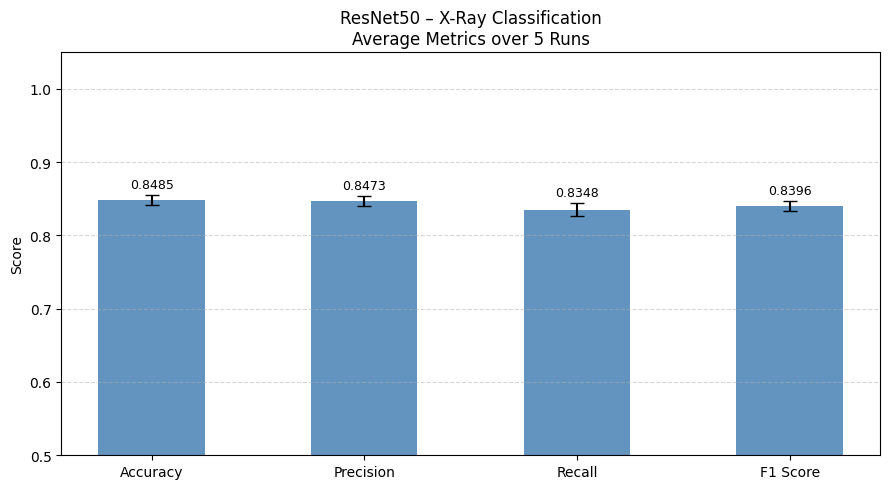

In [10]:
avg = df_results[metrics].mean()
std = df_results[metrics].std()

x     = np.arange(len(metrics))
width = 0.5

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(x, avg, width, yerr=std, color='steelblue', capsize=5, alpha=0.85)
ax.set_ylabel('Score')
ax.set_title('ResNet50 – X-Ray Classification\nAverage Metrics over 5 Runs')
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylim(0.5, 1.05)
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

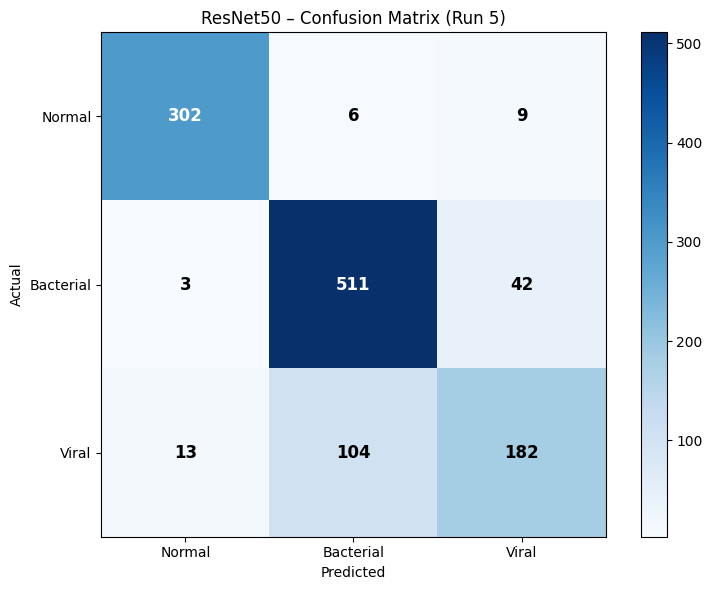

In [11]:
cm  = confusion_matrix(y_test_last, y_pred_last)
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')
fig.colorbar(im, ax=ax)
ax.set_xticks(range(3)); ax.set_yticks(range(3))
ax.set_xticklabels(CLASS_NAMES); ax.set_yticklabels(CLASS_NAMES)
for i in range(3):
    for j in range(3):
        ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                color='white' if cm[i,j] > cm.max()/2 else 'black',
                fontsize=12, fontweight='bold')
ax.set_title('ResNet50 – Confusion Matrix (Run 5)')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

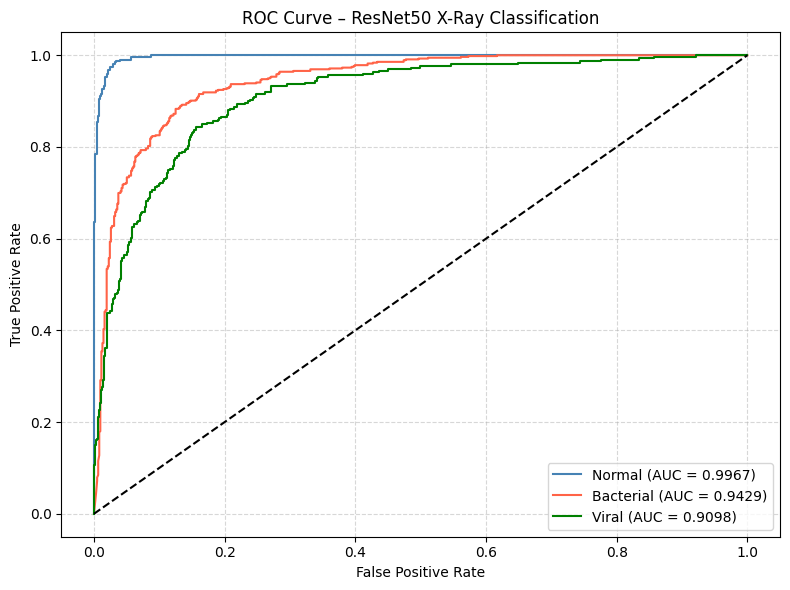

In [12]:
y_true_bin = label_binarize(y_test_last, classes=[0, 1, 2])
colors     = ['steelblue', 'tomato', 'green']

plt.figure(figsize=(8, 6))
for i, (cls_name, color) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs_last[:, i])
    roc_auc     = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, label=f'{cls_name} (AUC = {roc_auc:.4f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – ResNet50 X-Ray Classification')
plt.legend(); plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

In [13]:
print("===== ResNet50 – Classification Report (Run 5) =====")
print(classification_report(y_test_last, y_pred_last,
                             target_names=CLASS_NAMES))

===== ResNet50 – Classification Report (Run 5) =====
              precision    recall  f1-score   support

      Normal       0.95      0.95      0.95       317
   Bacterial       0.82      0.92      0.87       556
       Viral       0.78      0.61      0.68       299

    accuracy                           0.85      1172
   macro avg       0.85      0.83      0.83      1172
weighted avg       0.85      0.85      0.84      1172



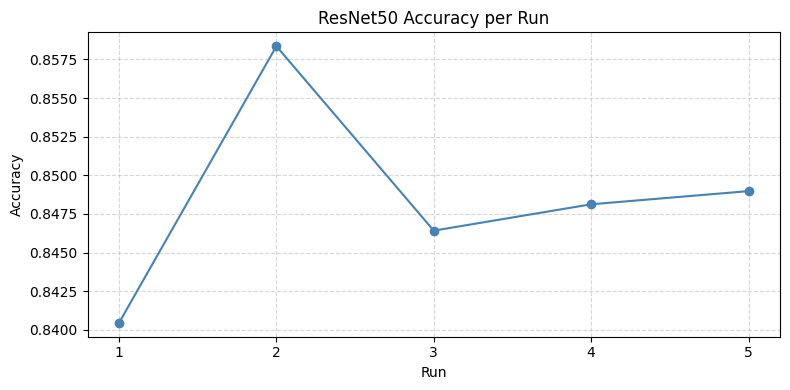

In [14]:
plt.figure(figsize=(8, 4))
plt.plot(df_results["Run"], df_results["Accuracy"], 'o-', color='steelblue')
plt.xlabel('Run'); plt.ylabel('Accuracy')
plt.title('ResNet50 Accuracy per Run')
plt.xticks(df_results["Run"])
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

In [15]:
!pip install opencv-python
import cv2
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image

class GradCAM:
    def __init__(self, model):
        self.model      = model
        self.gradients  = None
        self.activations = None

        # Hook into the last conv layer (layer4)
        model.layer4[-1].register_forward_hook(self._save_activations)
        model.layer4[-1].register_backward_hook(self._save_gradients)

    def _save_activations(self, module, input, output):
        self.activations = output.detach()

    def _save_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx):
        self.model.eval()
        output = self.model(input_tensor)

        self.model.zero_grad()
        output[0, class_idx].backward()

        # Weight the activations by the gradients
        weights     = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam         = (weights * self.activations).sum(dim=1).squeeze()
        cam         = torch.relu(cam)
        cam         = cam.cpu().numpy()

        # Normalize
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

C:\Users\bilsr\anaconda3\envs\m1_env\Lib\site-packages\torch\nn\modules\module.py:1842: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


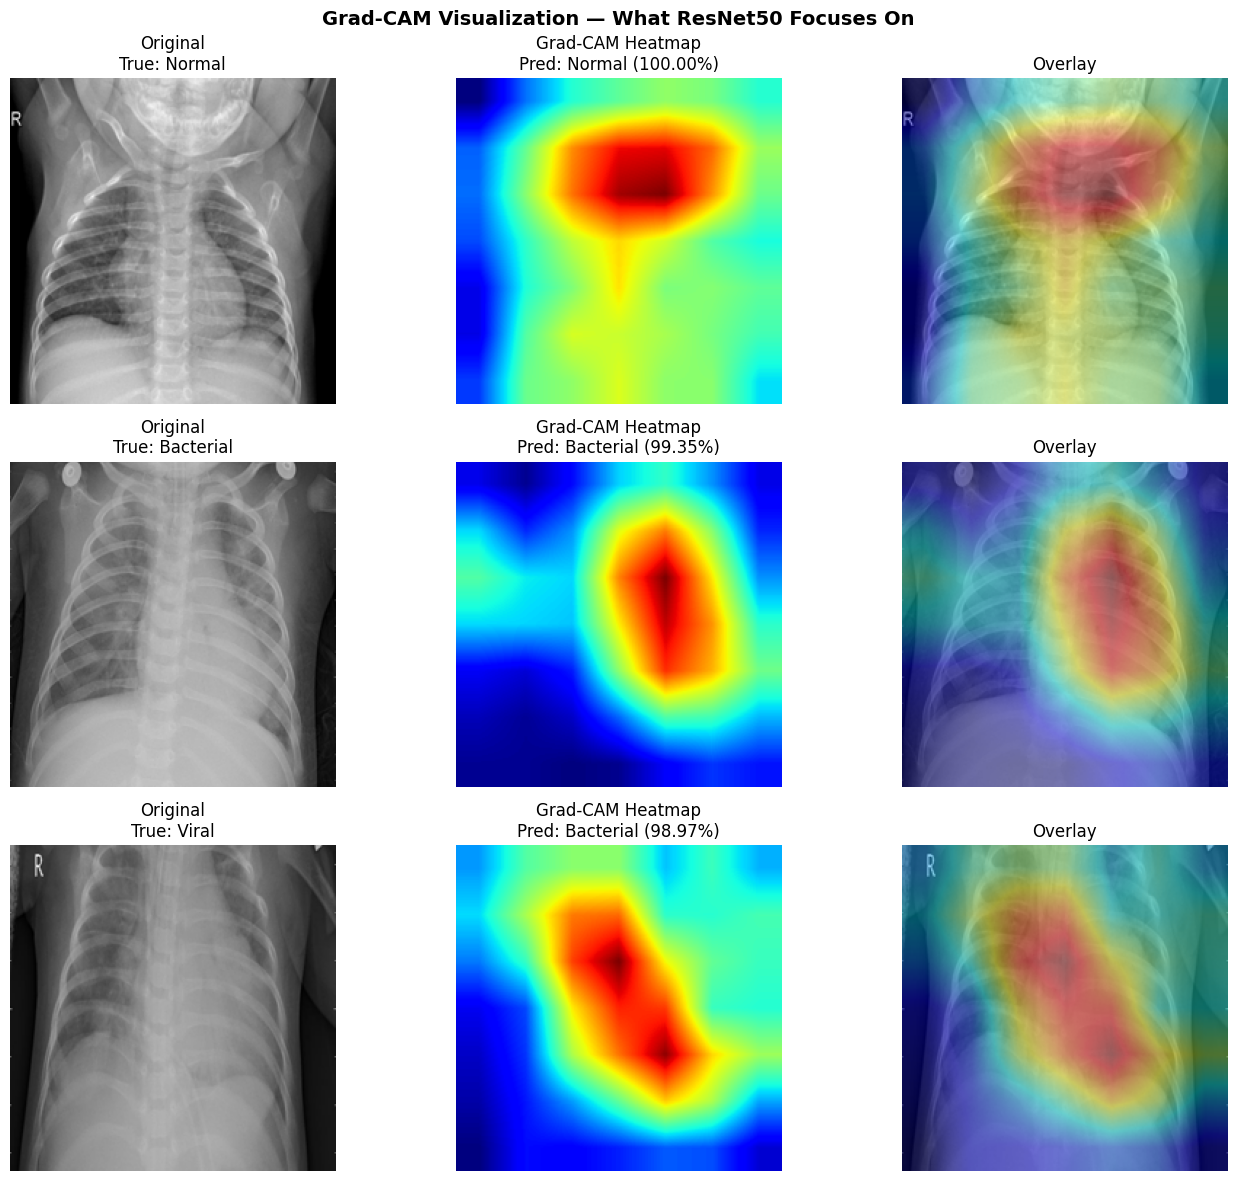

In [16]:
# Load the saved model
saved_model = build_resnet50().to(device)
saved_model.load_state_dict(torch.load(
    r'C:\Users\bilsr\OneDrive\Desktop\New folder\resnet50_xray.pth',
    map_location=device
))
saved_model.eval()

# Initialize Grad-CAM
gradcam = GradCAM(saved_model)

# Pick one sample from each class to visualize
samples_to_show = []
for class_idx in range(3):
    # Find first image of this class in test set
    idx = next(i for i, label in enumerate(y_test_last) if label == class_idx)
    samples_to_show.append((X_test[idx], class_idx))

fig, axes = plt.subplots(3, 3, figsize=(14, 12))

for row, (img_path, true_label) in enumerate(samples_to_show):
    # Load original image
    orig_img = Image.open(img_path).convert('RGB')
    orig_img = orig_img.resize((224, 224))
    orig_arr = np.array(orig_img)

    # Prepare tensor
    input_tensor = test_transform(orig_img).unsqueeze(0).to(device)

    # Get prediction
    with torch.no_grad():
        output     = saved_model(input_tensor)
        pred_label = torch.argmax(output).item()
        confidence = torch.softmax(output, dim=1)[0][pred_label].item()

    # Generate Grad-CAM
    cam = gradcam.generate(input_tensor, pred_label)

    # Resize CAM to image size
    cam_resized = cv2.resize(cam, (224, 224))
    heatmap     = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap     = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    # Overlay heatmap on original image
    overlay = (0.6 * orig_arr + 0.4 * heatmap).astype(np.uint8)

    # Plot original, heatmap and overlay
    axes[row, 0].imshow(orig_arr, cmap='gray')
    axes[row, 0].set_title(f'Original\nTrue: {CLASS_NAMES[true_label]}')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(cam_resized, cmap='jet')
    axes[row, 1].set_title(f'Grad-CAM Heatmap\nPred: {CLASS_NAMES[pred_label]} ({confidence:.2%})')
    axes[row, 1].axis('off')

    axes[row, 2].imshow(overlay)
    axes[row, 2].set_title('Overlay')
    axes[row, 2].axis('off')

plt.suptitle('Grad-CAM Visualization — What ResNet50 Focuses On',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()